# Feature Engineering and Selection

In [1]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier 


# Display settings
pd.set_option('display.max_columns', None)

# Plot style
sns.set_theme(style="darkgrid", palette="deep")

In [2]:
def wrangle_data(file_path):
    # Read data
    df = pd.read_csv(file_path)

    # Normalize text columns
    cat_cols = df.select_dtypes(include="str").columns

    # Exclude account_id if present
    cat_cols = [col for col in cat_cols if col != "account_id"]

    for col in cat_cols:
        df[col] = df[col].str.strip().str.title()

    # Fill missing numeric values with median
    num_cols = df.select_dtypes(include="number").columns

    for col in num_cols:
        df[col] = df[col].fillna(df[col].median())

    return df

In [3]:
file_path = "../data/raw/insightlysoft_dataset_uncleaned.csv"
df = wrangle_data(file_path)

df.head()

,account_id,monthly_login_freq,num_support_tickets,contract_length_months,avg_product_usage_hours,num_users,nps_score,has_admin_activity,last_activity_days_ago,avg_session_length,feature_adoption_score,customer_satisfaction_score,city,gender,churned
0,A0001,21.0,0,6,28.16,58,30.0,0,5,1.51,89.98,8.42,Chicago,Female,0
1,A0002,13.0,0,6,18.70,33,6.0,1,20,1.33,11.82,1.33,New York,Female,1
2,A0003,23.0,1,6,32.73,61,32.0,0,2,0.48,31.07,6.60,Austin,Female,0
3,A0004,20.0,1,6,9.25,4,30.0,0,34,2.04,77.84,5.07,Chicago,Male,1
4,A0005,20.0,5,24,29.08,99,30.0,0,4,1.92,54.32,5.07,Austin,Female,0


## Feature Engineering

In [4]:
df = df.assign(
        usage_per_user = df["avg_product_usage_hours"] / df["num_users"],
        ticket_per_user = df["num_support_tickets"] / df["num_users"],
        engagement_score = df["monthly_login_freq"] * df["avg_session_length"]
    )

df.head()

,account_id,monthly_login_freq,num_support_tickets,contract_length_months,avg_product_usage_hours,num_users,nps_score,has_admin_activity,last_activity_days_ago,avg_session_length,feature_adoption_score,customer_satisfaction_score,city,gender,churned,usage_per_user,ticket_per_user,engagement_score
0,A0001,21.0,0,6,28.16,58,30.0,0,5,1.51,89.98,8.42,Chicago,Female,0,0.485517,0.000000,31.71
1,A0002,13.0,0,6,18.70,33,6.0,1,20,1.33,11.82,1.33,New York,Female,1,0.566667,0.000000,17.29
2,A0003,23.0,1,6,32.73,61,32.0,0,2,0.48,31.07,6.60,Austin,Female,0,0.536557,0.016393,11.04
3,A0004,20.0,1,6,9.25,4,30.0,0,34,2.04,77.84,5.07,Chicago,Male,1,2.312500,0.250000,40.80
4,A0005,20.0,5,24,29.08,99,30.0,0,4,1.92,54.32,5.07,Austin,Female,0,0.293737,0.050505,38.40


## AI-Assisted Feature Generation

In [5]:
# Complex engagement metric
df["weighted_engagement"] = (
    df["monthly_login_freq"] *
    df["feature_adoption_score"] /
    (df["last_activity_days_ago"] + 1)
)


# Customer health score
df["health_score"] = (
    df["customer_satisfaction_score"] * 0.4 + 
    df["nps_score"].clip(-100, 100) / 100 * 0.3 +
    df["feature_adoption_score"] / 100 * 0.3
)

df.head()

,account_id,monthly_login_freq,num_support_tickets,contract_length_months,avg_product_usage_hours,num_users,nps_score,has_admin_activity,last_activity_days_ago,avg_session_length,feature_adoption_score,customer_satisfaction_score,city,gender,churned,usage_per_user,ticket_per_user,engagement_score,weighted_engagement,health_score
0,A0001,21.0,0,6,28.16,58,30.0,0,5,1.51,89.98,8.42,Chicago,Female,0,0.485517,0.000000,31.71,314.930000,3.72794
1,A0002,13.0,0,6,18.70,33,6.0,1,20,1.33,11.82,1.33,New York,Female,1,0.566667,0.000000,17.29,7.317143,0.58546
2,A0003,23.0,1,6,32.73,61,32.0,0,2,0.48,31.07,6.60,Austin,Female,0,0.536557,0.016393,11.04,238.203333,2.82921
3,A0004,20.0,1,6,9.25,4,30.0,0,34,2.04,77.84,5.07,Chicago,Male,1,2.312500,0.250000,40.80,44.480000,2.35152
4,A0005,20.0,5,24,29.08,99,30.0,0,4,1.92,54.32,5.07,Austin,Female,0,0.293737,0.050505,38.40,217.280000,2.28096


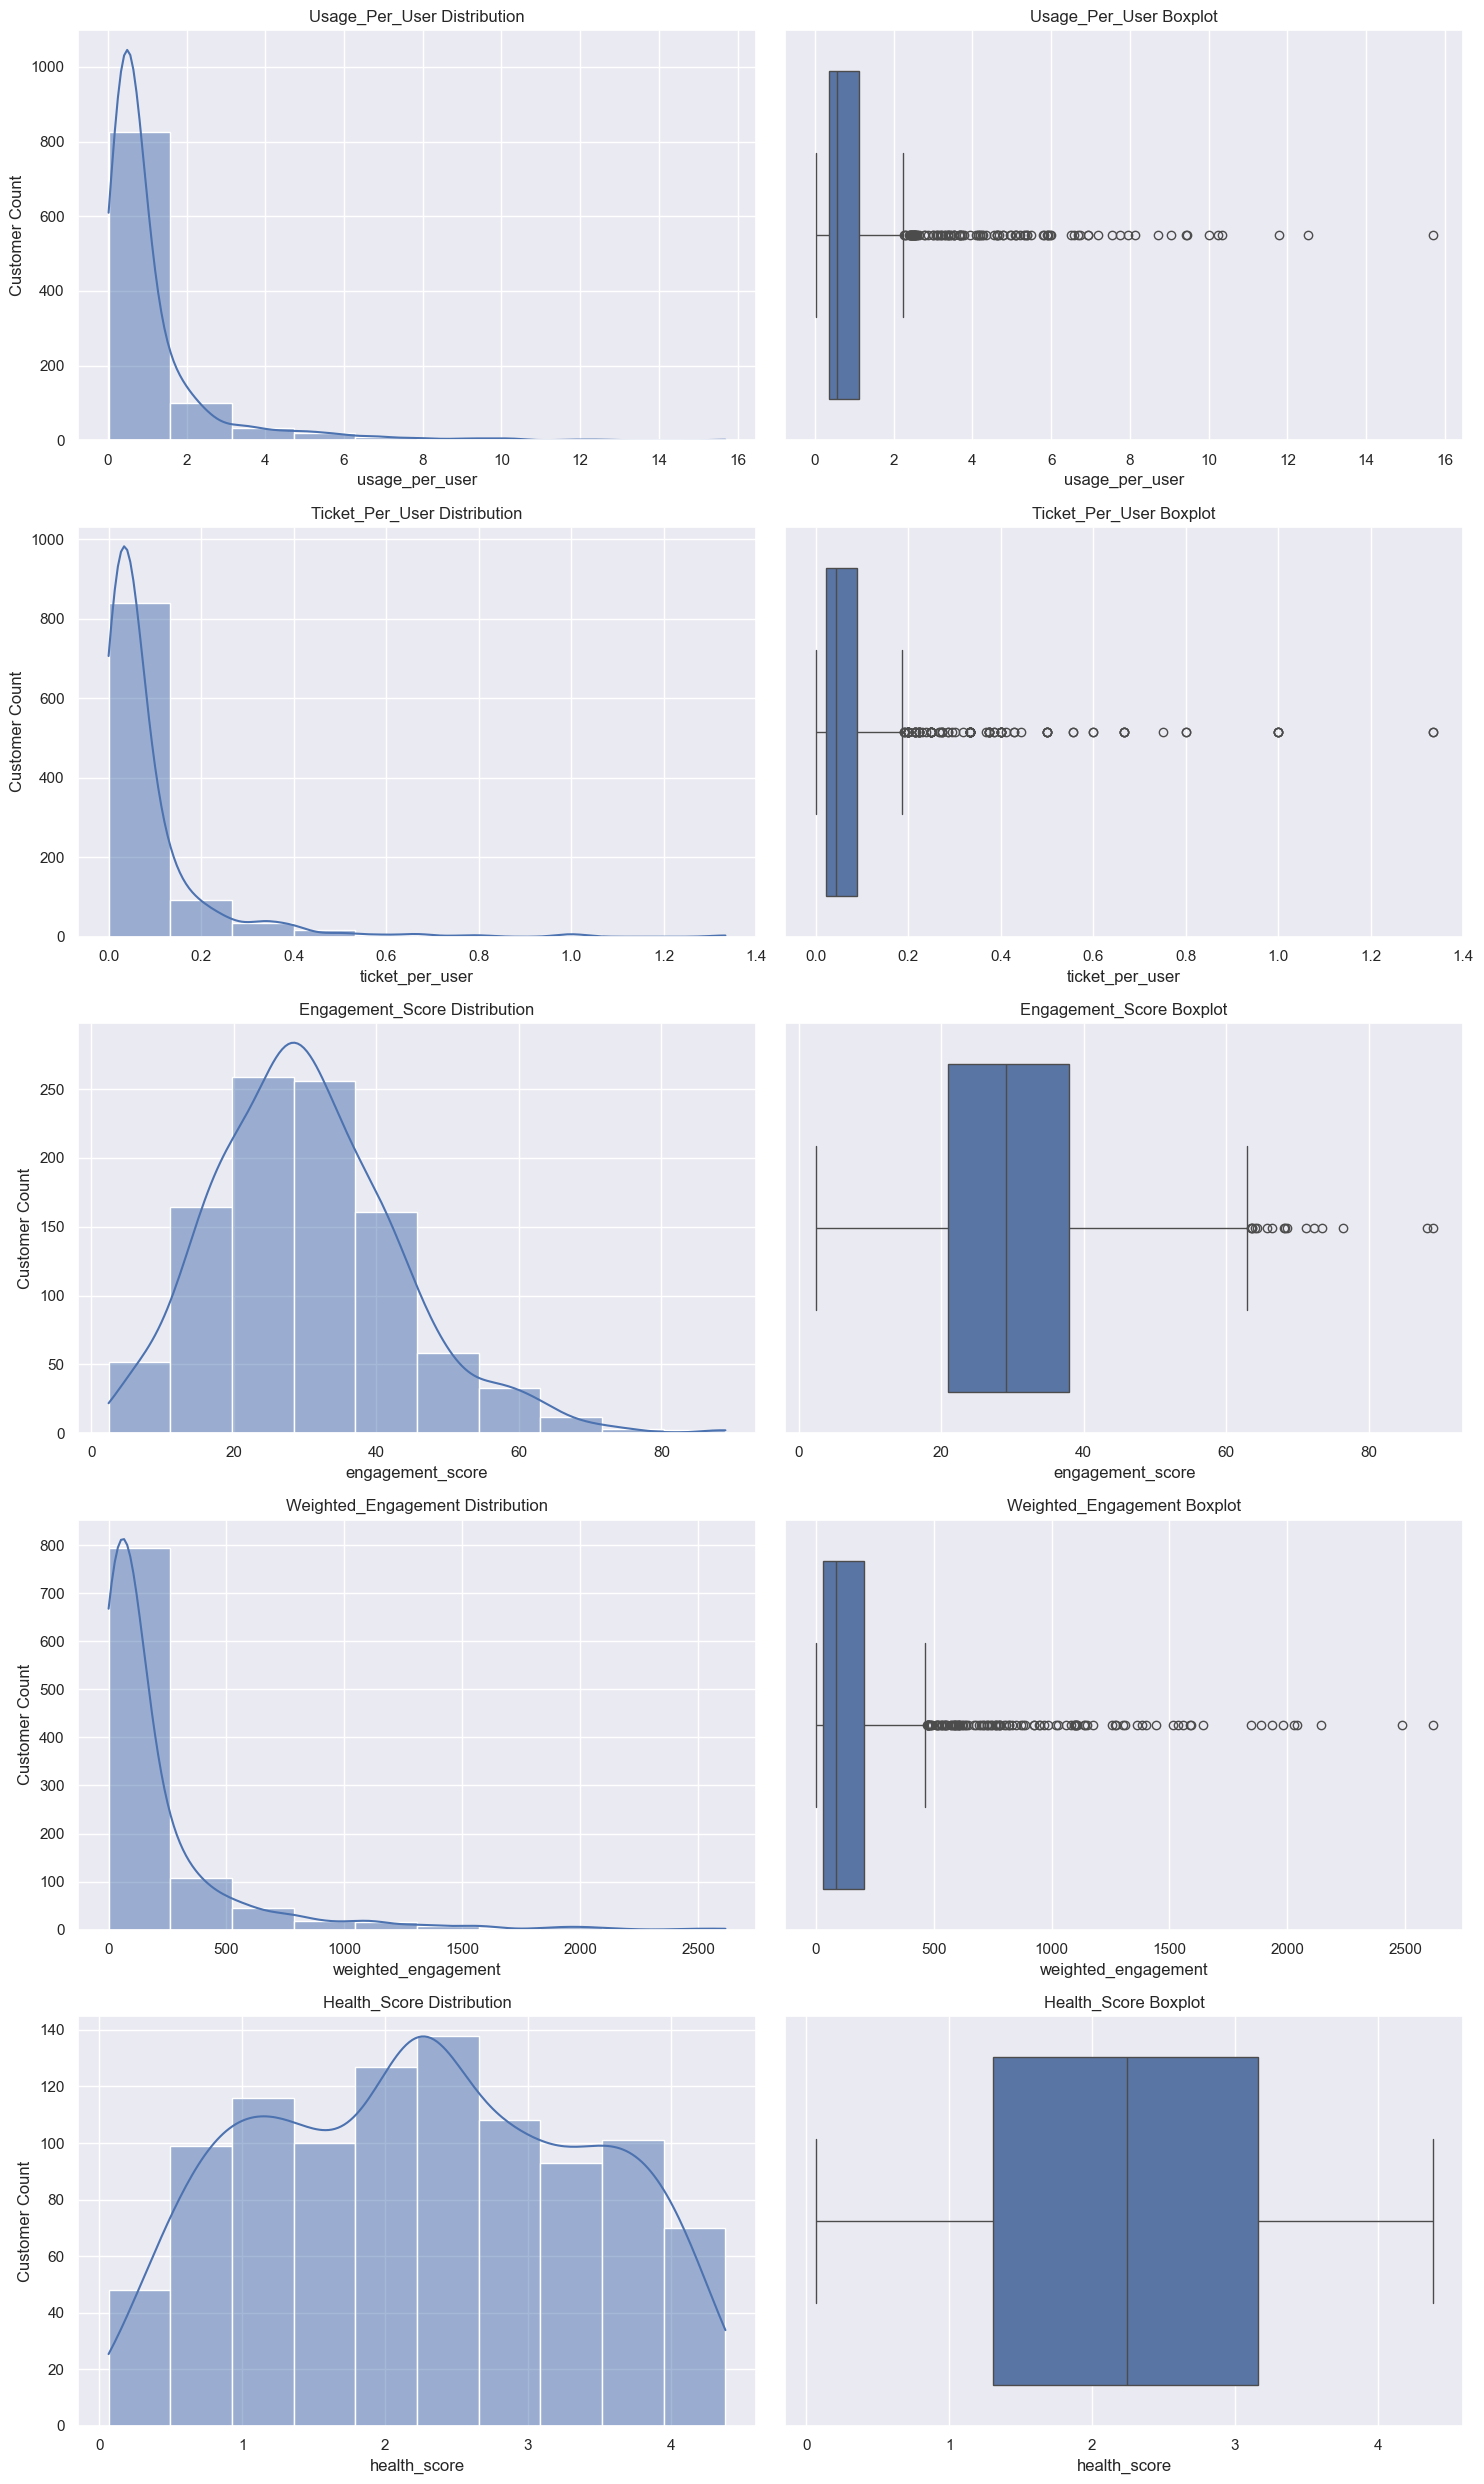

In [6]:
# Explore numeric variables
num_cols = ["usage_per_user", "ticket_per_user", "engagement_score", "weighted_engagement", "health_score"]
n_row = len(num_cols)
n_col = 2

fig, axs = plt.subplots(n_row, n_col, figsize=(15, 5 * n_row))

for i, col in enumerate(num_cols):
    sns.histplot(
        data=df,
        x=col,
        bins=10,
        kde=True,
        ax=axs[i, 0]
    ).set(
        xlabel=col,
        ylabel="Customer Count",
        title=f"{col.title()} Distribution"
    )

    sns.boxplot(
        data=df,
        x=col,
        ax=axs[i, 1]
    ).set(
        xlabel=col,
        title=f"{col.title()} Boxplot"
    )

plt.tight_layout()

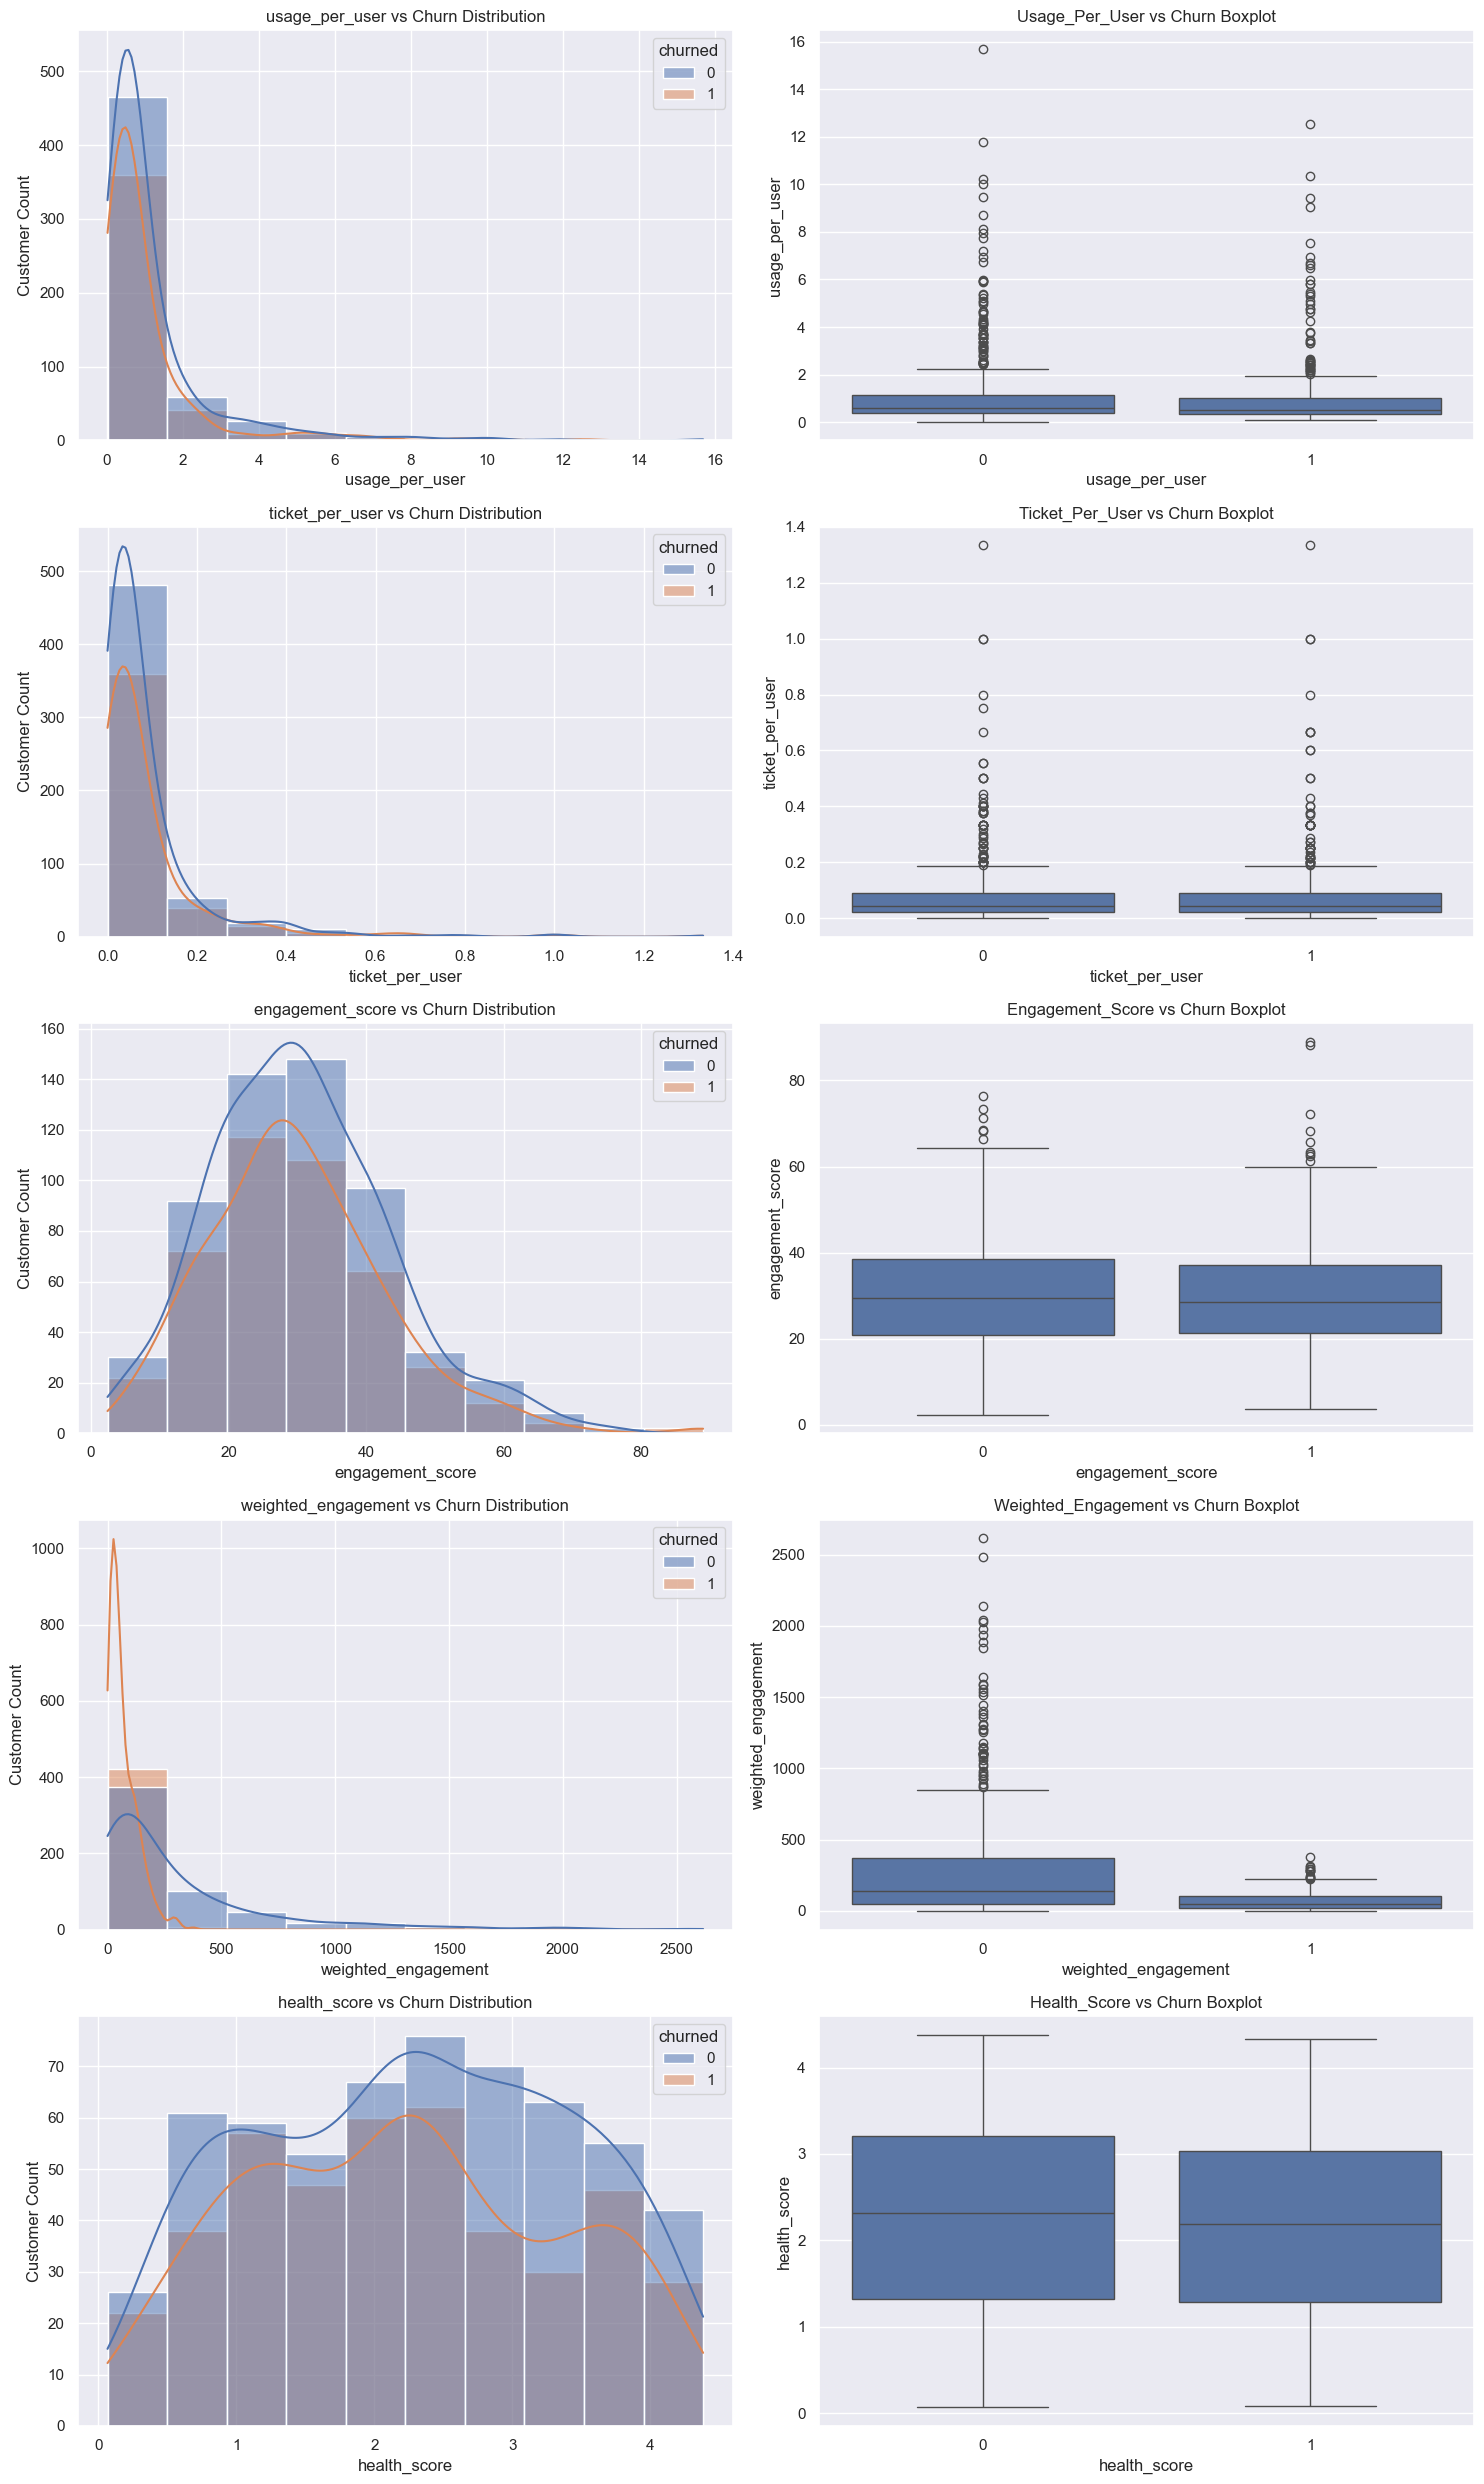

In [7]:
# Exploring the relationship b/w the new features generated and churn status

n_row = len(num_cols)
n_col = 2

fig, axs = plt.subplots(n_row, n_col, figsize=(15, 5 * n_row))

for i, col in enumerate(num_cols):
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        bins=10,
        hue="churned",
        ax=axs[i, 0]
    ).set(
        xlabel=col,
        ylabel="Customer Count", 
        title=f"{col} vs Churn Distribution"
    )

    sns.boxplot(
        data=df,
        x="churned",
        y=col,
        ax=axs[i, 1]
    ).set(
        xlabel=col,
        title=f"{col.title()} vs Churn Boxplot"
    )

plt.tight_layout()

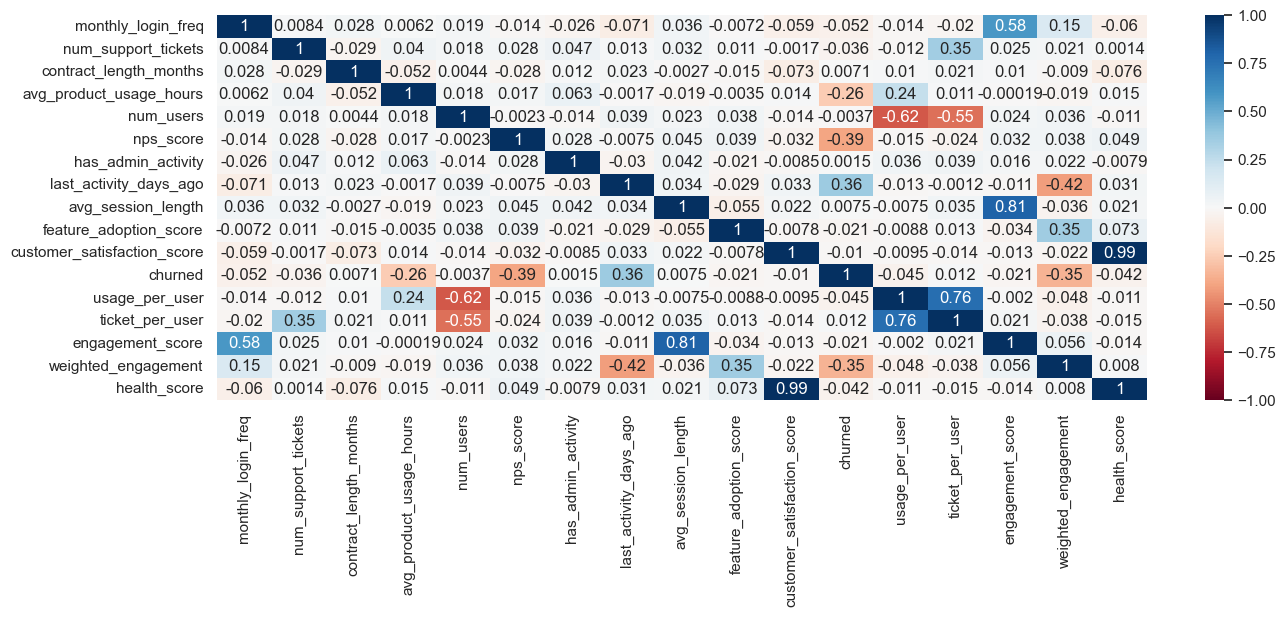

In [8]:
# check for correlation
plt.figure(figsize=(15, 5))
sns.heatmap(df.corr(numeric_only=True), vmin=-1, vmax=1, cmap="RdBu", annot=True);

## Feature Evaluation and Selection

In [9]:
# One-hot encoding categorical features
df = pd.get_dummies(
    df.drop("account_id", axis=1),
    drop_first=True,
    dtype="int"
)

df.head()

,monthly_login_freq,num_support_tickets,contract_length_months,avg_product_usage_hours,num_users,nps_score,has_admin_activity,last_activity_days_ago,avg_session_length,feature_adoption_score,customer_satisfaction_score,churned,usage_per_user,ticket_per_user,engagement_score,weighted_engagement,health_score,city_Chicago,city_New York,city_San Francisco,gender_Male
0,21.0,0,6,28.16,58,30.0,0,5,1.51,89.98,8.42,0,0.485517,0.000000,31.71,314.930000,3.72794,1,0,0,0
1,13.0,0,6,18.70,33,6.0,1,20,1.33,11.82,1.33,1,0.566667,0.000000,17.29,7.317143,0.58546,0,1,0,0
2,23.0,1,6,32.73,61,32.0,0,2,0.48,31.07,6.60,0,0.536557,0.016393,11.04,238.203333,2.82921,0,0,0,0
3,20.0,1,6,9.25,4,30.0,0,34,2.04,77.84,5.07,1,2.312500,0.250000,40.80,44.480000,2.35152,1,0,0,1
4,20.0,5,24,29.08,99,30.0,0,4,1.92,54.32,5.07,0,0.293737,0.050505,38.40,217.280000,2.28096,0,0,0,0


### Mutual Information Score

In [10]:
# Evaluating numeric features using the mutual_info_classif
X = df.drop("churned", axis=1)
y = df["churned"]

# Mutual Information Scores
mi_scores = mutual_info_classif(X, y, random_state=42)

mi_feature_importance = pd.DataFrame({
    "importance":mi_scores,
    "feature":X.columns
}).sort_values(by="importance", ascending=False)


### Random Forest (using default parameters)

In [11]:
rf = RandomForestClassifier(random_state=42)

# fitting model
rf.fit(X, y)

# Random Forest feature importance
rf_feature_importance = pd.DataFrame({
    "feature":X.columns,
    "importance":rf.feature_importances_
}).sort_values(by="importance", ascending=False)

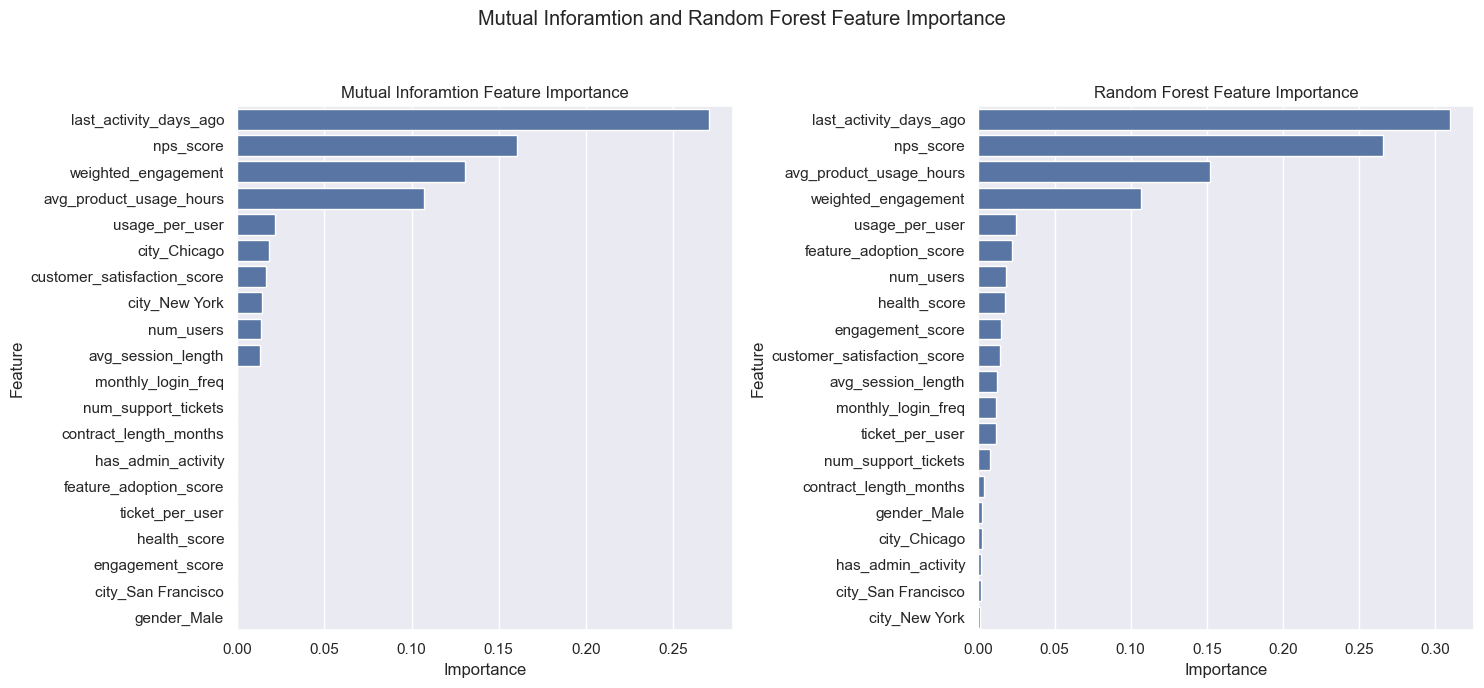

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

sns.barplot(
    data=mi_feature_importance,
    x="importance",
    y="feature",
    ax=axs[0]
).set(
    xlabel="Importance",
    ylabel="Feature",
    title="Mutual Inforamtion Feature Importance"
)


sns.barplot(
    data=rf_feature_importance,
    x="importance",
    y="feature",
    ax=axs[1]
).set(
    xlabel="Importance",
    ylabel="Feature",
    title="Random Forest Feature Importance"
)


fig.suptitle("Mutual Inforamtion and Random Forest Feature Importance")

plt.tight_layout(rect=[0, 0, 1, 0.95])

#### Selected Features
1. last_activity_days_ago
2. nps_score
3. avg_product_usage_hours
4. weighted_engagement
5. usage_per_user


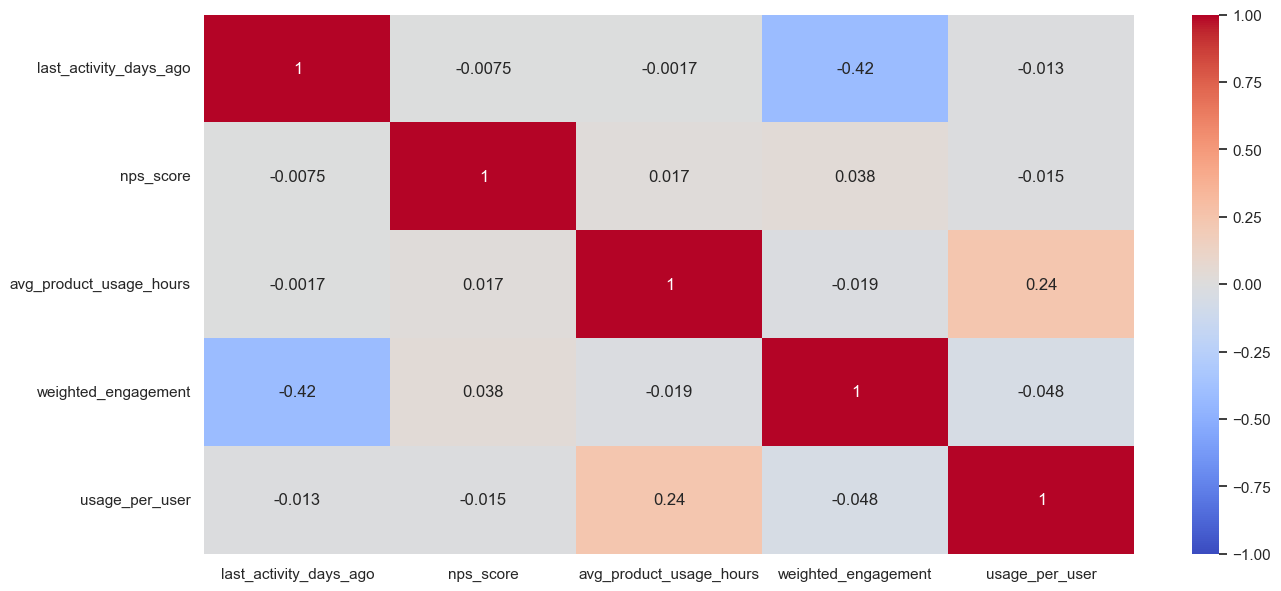

In [13]:
features = [
    "last_activity_days_ago",
    "nps_score",
    "avg_product_usage_hours",
    "weighted_engagement",
    "usage_per_user"
]

plt.figure(figsize=(15, 7))
sns.heatmap(df[features].corr(), vmin=-1, vmax=1, annot=True, cmap="coolwarm");

In [14]:
modelling_df = df[features]
modelling_df

,last_activity_days_ago,nps_score,avg_product_usage_hours,weighted_engagement,usage_per_user
0,5,30.0,28.16,314.930000,0.485517
1,20,6.0,18.70,7.317143,0.566667
2,2,32.0,32.73,238.203333,0.536557
3,34,30.0,9.25,44.480000,2.312500
4,4,30.0,29.08,217.280000,0.293737
...,...,...,...,...,...
995,7,37.0,21.29,27.195000,0.686774
996,13,45.0,37.25,107.627143,0.423295
997,1,30.0,34.48,550.300000,0.733617
998,4,-4.0,28.41,165.840000,0.359620
